## Урок 10. Домашнее задание

### 10.1 Домашнее задание начального уровня

Обучите *k-means* для количества кластеров $k=4$ на датасете `data/clustering.pkl`. Как изменилась метрика силуэтта? Стало лучше или хуже? Какое количество кластеров лучше, два или четыре?

In [1]:
import pickle
import numpy as np

# данные получены с помощью функции make_classification 
file_path = 'C:/Users/user0907/clustering.pkl'
with open(file_path, 'rb') as f:
    data_clustering = pickle.load(f)

X = np.array(data_clustering['X'])
Y = np.array(data_clustering['Y'])



In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
from sklearn.cluster import KMeans

model = KMeans(n_clusters=4).fit(X)

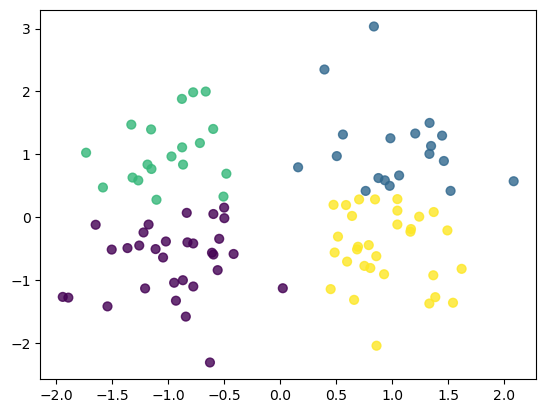

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.scatter(X[:, 0], X[:, 1], s=40, c=model.labels_, marker='o', alpha=0.8)
plt.show()

In [13]:
from sklearn.metrics import silhouette_score

for i in range(2,5):
    model = KMeans(n_clusters=i).fit(X)
    score = silhouette_score(X, model.labels_)

    print(f"Качество кластеризации c {i} кластерам(и) по метрике AMI {score:.3f}")
#метрика силуэта c 4 кластерами хуже на 9 тясячных в отличие от метрики с тремя кластерами, показатель 0,5 не достигнут

Качество кластеризации c 2 кластерам(и) по метрике AMI 0.291
Качество кластеризации c 3 кластерам(и) по метрике AMI 0.451
Качество кластеризации c 4 кластерам(и) по метрике AMI 0.442



### 10.2 Домашнее задание начального уровня

Обучите *k-means* для количества кластеров $k=4$ на датасете `data/clustering.pkl`. Как изменилась метрика *AMI*? Стало лучше или хуже? Какое количество кластеров лучше по метрике AMI?

In [11]:
from sklearn.metrics.cluster import adjusted_mutual_info_score
for i in range(2,5):
    model = KMeans(n_clusters=i).fit(X)
    score = adjusted_mutual_info_score(Y, model.labels_, average_method='arithmetic')

    print(f"Качество кластеризации c {i} кластерам(и) по метрике AMI {score:.3f}")
#метрика силуэта c 4 кластерами имеет среднее качетсво


Качество кластеризации c 2 кластерам(и) по метрике AMI 0.929
Качество кластеризации c 3 кластерам(и) по метрике AMI 0.447
Качество кластеризации c 4 кластерам(и) по метрике AMI 0.632



### 10.3 Домашнее задание высокого уровня

Загрузите датасет `clustering_hw.csv` из приложенной директории `data` и визуализируйте данные. Должно получится как-то так:

![clustering_hw](https://248006.selcdn.ru/public/DS.%20Block%202.%20M7/clustering_hw.png)

В рамках домашней работы

1. вычислите оптимальное количество кластеров $k$
1. обучите k-means с количеством кластеров  $k$
1. к какому кластеру принадлежит точка $x=(5, 8)$? к какому кластеру принадлежит точка $x=(0, 5)$? Они принадлежат к разным кластерам или одному?
1. Каково качество кластеризации по AMI

In [15]:
import pandas as pd
df = pd.read_csv('clustering_hw_lH0WPG4.csv')
df.head()



,x1,x2,y
0,6.221343,4.968753,2
1,7.360892,8.857455,2
2,-0.108178,4.730723,1
3,3.127358,1.927986,0
4,-0.817259,6.759974,1


In [44]:
X = np.column_stack([df['x1'], df['x2']]) 
Y = df['y'].values.ravel()

In [49]:
#используем silhouette_score
from sklearn.metrics import silhouette_score
optim = 0
k = 0
for i in range(2,10):
    model = KMeans(n_clusters=i).fit(X)
    score = silhouette_score(X, model.labels_)
    if score > optim:
        optim = score
        k = i
    print(f"Качество кластеризации c {i} кластерам(и) по метрике AMI {score:.3f}")
print("\nОптимальное количество кластеров:", k)

Качество кластеризации c 2 кластерам(и) по метрике AMI 0.564
Качество кластеризации c 3 кластерам(и) по метрике AMI 0.651
Качество кластеризации c 4 кластерам(и) по метрике AMI 0.533
Качество кластеризации c 5 кластерам(и) по метрике AMI 0.416
Качество кластеризации c 6 кластерам(и) по метрике AMI 0.428
Качество кластеризации c 7 кластерам(и) по метрике AMI 0.323
Качество кластеризации c 8 кластерам(и) по метрике AMI 0.330
Качество кластеризации c 9 кластерам(и) по метрике AMI 0.334

Оптимальное количество кластеров: 3


In [50]:
#используем AMI
from sklearn.metrics.cluster import adjusted_mutual_info_score
optim = 0
k = 0
for i in range(2,10):
    model = KMeans(n_clusters=i).fit(X)
    score = adjusted_mutual_info_score(Y, model.labels_, average_method='arithmetic')
    if score > optim:
        optim = score
        k = i
    print(f"Качество кластеризации с {i} кластерами по метрике AMI: {score:.3f}")
print("\nОптимальное количество кластеров по АМИ:", k)

Качество кластеризации с 2 кластерами по метрике AMI: 0.698
Качество кластеризации с 3 кластерами по метрике AMI: 0.970
Качество кластеризации с 4 кластерами по метрике AMI: 0.872
Качество кластеризации с 5 кластерами по метрике AMI: 0.779
Качество кластеризации с 6 кластерами по метрике AMI: 0.711
Качество кластеризации с 7 кластерами по метрике AMI: 0.686
Качество кластеризации с 8 кластерами по метрике AMI: 0.648
Качество кластеризации с 9 кластерами по метрике AMI: 0.631

Оптимальное количество кластеров по АМИ: 3


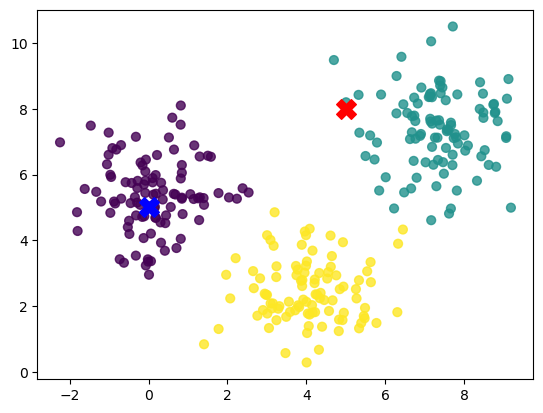

In [62]:
#визуализация
model = KMeans(n_clusters=k).fit(X)
score = silhouette_score(X, model.labels_)
import matplotlib.pyplot as plt
%matplotlib inline

plt.scatter(X[:, 0], X[:, 1], s=40, c=model.labels_, marker='o', alpha=0.8)
plt.scatter(5, 8, s=200, c='red', marker='X', alpha=1.0, label='Point (5,8)')
plt.scatter(0, 5, s=200, c='blue', marker='X', alpha=1.0, label='Point (0,5)')
plt.show()
#выводы:к какому кластеру принадлежит точка x = (5,8)? к какому кластеру принадлежит точка x = (0,5)? Они принадлежат к разным кластерам или одному? 
#ответ: x = (5,8) принадлежит ко 2 кластеру, x = (0,5) принадлежит ко 1 кластеру. Кластеры разные.
#Каково качество кластеризации по AMI
#ответ: Качество кластеризации с 3 кластерами по метрике AMI: 0.970 - лучшее из исследованных

### Заключение

Мы познакомились с двумя метриками

* Silhouette. Её используем, когда есть только сами объекты, а метки кластеров отсутствуют в обучающей выборке
* AMI. Её используем, когда известны "истинные" метки кластеров

Метрик намного больше - о них можно почитать [ в документации sklearn](https://scikit-learn.org/stable/modules/classes.html#clustering-metrics)